### 1. Introduction
E-commerce websites frequently conduct A/B testing to evaluate changes in their website design and pricing strategies. This project analyzes an A/B testing experiment to compare the performance of an existing webpage (Control) with a new webpage (Treatment).

Using ab_data.csv and countries.csv, the analysis examines user conversion behavior and explores whether the new page leads to a difference in conversion rates across experiment groups and countries.

The project involves data cleaning, exploratory data analysis (EDA), data visualization, and statistical hypothesis testing to determine whether the observed differences in conversion rates are statistically significant.

The primary objective is to use data-driven evidence to understand the effectiveness of the new webpage and support informed business decisions regarding its implementation.

### 2. Data Description
This project uses two datasets, `ab_data.csv` and `countries.csv`, to analyze the results of an A/B testing experiment conducted on an e-commerce website.

* **ab_data.csv:** Contains user-level experiment data, including user ID, timestamp, experiment group, landing page, and conversion status.
* **countries.csv:** Contains user ID and country information, which allows conversion behavior to be analyzed across different geographical regions.

The datasets are used to compare the conversion rates of the control and treatment groups and investigate whether the new landing page leads to a statistically significant change in user conversions.


#### 2.1 Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

#### 2.2 Loading Datasets

In [3]:
ab_data=pd.read_csv("ab_data.csv")
countries=pd.read_csv("countries.csv")
print("Loaded Successfully")

Loaded Successfully


#### 2.3 Inspecting Dataset

In [4]:
print("A/B Testing Dataset:")
display(ab_data.head())

print("Countries Dataset:")
display(countries.head())

A/B Testing Dataset:


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


Countries Dataset:


,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


In [5]:
print("ab_data Dimensions=",ab_data.shape)
print("countries Dimensions=",countries.shape)

ab_data Dimensions= (294478, 5)
countries Dimensions= (290584, 2)


In [6]:
ab_data.info()
countries.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB
<class 'pandas.DataFrame'>
RangeIndex: 290584 entries, 0 to 290583
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   user_id  290584 non-null  int64
 1   country  290584 non-null  str  
dtypes: int64(1), str(1)
memory usage: 4.4 MB


In [7]:
ab_data.isnull().sum()
countries.isnull().sum()

user_id    0
country    0
dtype: int64

In [8]:
print("Duplicate rows in A/B Dataset:",
      ab_data.duplicated().sum())
print("Duplicate rows in Countries Dataset:",
      countries.duplicated().sum())
print("Duplicate user IDs in A/B Dataset:",
      ab_data["user_id"].duplicated().sum())
print("Duplicate user IDs in Countries Dataset:",
      countries["user_id"].duplicated().sum())

Duplicate rows in A/B Dataset: 0
Duplicate rows in Countries Dataset: 0
Duplicate user IDs in A/B Dataset: 3894
Duplicate user IDs in Countries Dataset: 0


In [9]:
print("Experiment Group Distribution:")
print(ab_data["group"].value_counts())

print("\nLanding Page Distribution:")
print(ab_data["landing_page"].value_counts())

display(pd.crosstab(
    ab_data["group"],
    ab_data["landing_page"]
))


Experiment Group Distribution:
group
treatment    147276
control      147202
Name: count, dtype: int64

Landing Page Distribution:
landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64


landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


In [10]:
print("A/B Dataset Missing Values:")
print(ab_data.isnull().sum())

print("\nCountries Dataset Missing Values:")
print(countries.isnull().sum())

A/B Dataset Missing Values:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

Countries Dataset Missing Values:
user_id    0
country    0
dtype: int64


In [11]:
print("Negative values in in user_id col of ab_data ",
    (ab_data["user_id"]<0).sum()
)
print("Negative values in in converted col of ab_data ",
    (ab_data["converted"]<0).sum()
)
print("Negative values in in user_id col of ab_data ",
    (countries["user_id"]<0).sum()
)

Negative values in in user_id col of ab_data  0
Negative values in in converted col of ab_data  0
Negative values in in user_id col of ab_data  0


#### 2.4 Cleaning Dataset 

In [12]:
ab_clean=ab_data[
    ((ab_data["landing_page"]=="old_page") & (ab_data["group"]=="control")) |
    ((ab_data["landing_page"]=="new_page") & (ab_data["group"]=="treatment"))
].copy()
print("Before cleaning:",ab_data.shape)
print("After cleaning:",ab_clean.shape)
print(len(ab_data)-len(ab_clean))

Before cleaning: (294478, 5)
After cleaning: (290585, 5)
3893


In [13]:
print("Final Dataset shape",ab_clean.shape)
print("Remainig Duplicate",ab_data["user_id"].duplicated().sum())
print("Missing values",ab_data.isnull().sum())
display(pd.crosstab(
    ab_clean["group"],
    ab_clean["landing_page"]
))

Final Dataset shape (290585, 5)
Remainig Duplicate 3894
Missing values user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64


landing_page,new_page,old_page
group,,
control,0,145274
treatment,145311,0


In [14]:
print(ab_data["user_id"].duplicated().sum())
print(countries["user_id"].duplicated().sum())
print("Duplicates in cleaned data:",
      ab_clean["user_id"].duplicated().sum())

3894
0
Duplicates in cleaned data: 1


In [15]:
duplicates = ab_clean[
    ab_clean["user_id"].duplicated(keep=False)
]

display(duplicates)

,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


In [16]:
ab_clean=ab_clean.drop_duplicates(
    subset="user_id",
    keep="first"
).copy()
print(ab_clean["user_id"].duplicated().sum())

0


### OBSERVATION
The dataset was checked for duplicate user IDs to ensure that each user was counted only once. After removing mismatched group-page records, the remaining duplicate user ID was removed by retaining its first occurrence. The cleaned dataset was then validated to confirm that no duplicate user IDs remained.

## 3. Data Merging

We'll combine ab_clean with countries using the common user_id column.
This will allow us to analyze conversion rates by country as well as experiment group.

In [17]:
df=pd.merge(
    ab_clean,countries,
    on="user_id",
    how="inner"
)
print("Merged Dataset Shape:",df.shape)
print(df.head)

Merged Dataset Shape: (290584, 6)
<bound method NDFrame.head of         user_id                   timestamp      group landing_page  \
0        851104  2017-01-21 22:11:48.556739    control     old_page   
1        804228  2017-01-12 08:01:45.159739    control     old_page   
2        661590  2017-01-11 16:55:06.154213  treatment     new_page   
3        853541  2017-01-08 18:28:03.143765  treatment     new_page   
4        864975  2017-01-21 01:52:26.210827    control     old_page   
...         ...                         ...        ...          ...   
290579   751197  2017-01-03 22:28:38.630509    control     old_page   
290580   945152  2017-01-12 00:51:57.078372    control     old_page   
290581   734608  2017-01-22 11:45:03.439544    control     old_page   
290582   697314  2017-01-15 01:20:28.957438    control     old_page   
290583   715931  2017-01-16 12:40:24.467417  treatment     new_page   

        converted country  
0               0      US  
1               0      US  

In [18]:
print("Missing values after merging:")
print(df.isnull().sum())

print("\nDuplicate user IDs after merging:")
print(df["user_id"].duplicated().sum())

Missing values after merging:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
country         0
dtype: int64

Duplicate user IDs after merging:
0


### Observation
The cleaned A/B testing dataset was merged with the countries dataset using the common `user_id` column through an inner join. This enabled the integration of experiment and geographical information for further analysis. After merging, the resulting dataset was validated for missing values and duplicate user IDs. No missing values or duplicate user IDs were found in the merged dataset.


## 4. EDA

In [19]:
print(df["converted"].value_counts())
print(df["converted"].value_counts(normalize=True)*100)

converted
0    255831
1     34753
Name: count, dtype: int64
converted
0    88.040291
1    11.959709
Name: proportion, dtype: float64


In [20]:
display(pd.crosstab(
    df["group"],
    df["converted"]
))
# Conversion rate by group
conversion_rate=df.groupby("group")["converted"].mean()*100

print("Conversion Rate by Group:")
print(conversion_rate)

converted,0,1
group,,
control,127785,17489
treatment,128046,17264


Conversion Rate by Group:
group
control      12.038630
treatment    11.880807
Name: converted, dtype: float64


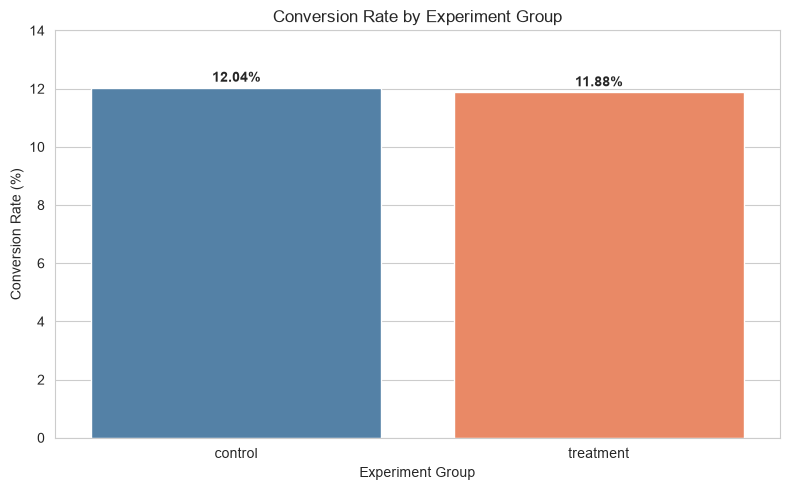

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate conversion rate by group
conversion_rate=df.groupby("group")["converted"].mean()*100

# Set plot style
sns.set_style("whitegrid")

# bar chart
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=conversion_rate.index,
    y=conversion_rate.values,
    hue=conversion_rate.index,
    palette=["steelblue", "coral"],
    
)

#percentage labels
for i, value in enumerate(conversion_rate.values):
    ax.text(
        i, value + 0.2,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.title("Conversion Rate by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, 14)

plt.tight_layout()
plt.show()

In [ ]:
#conversion rate by country and group
country_conversion = (
    df.groupby(["country", "group"])["converted"].mean() * 100
    
)

print("Conversion Rate by Country and Group:",country_conversion)


Conversion Rate by Country and Group: country  group    
CA       control      11.878300
         treatment    11.190248
UK       control      12.002200
         treatment    12.117100
US       control      12.062999
         treatment    11.846560
Name: converted, dtype: float64


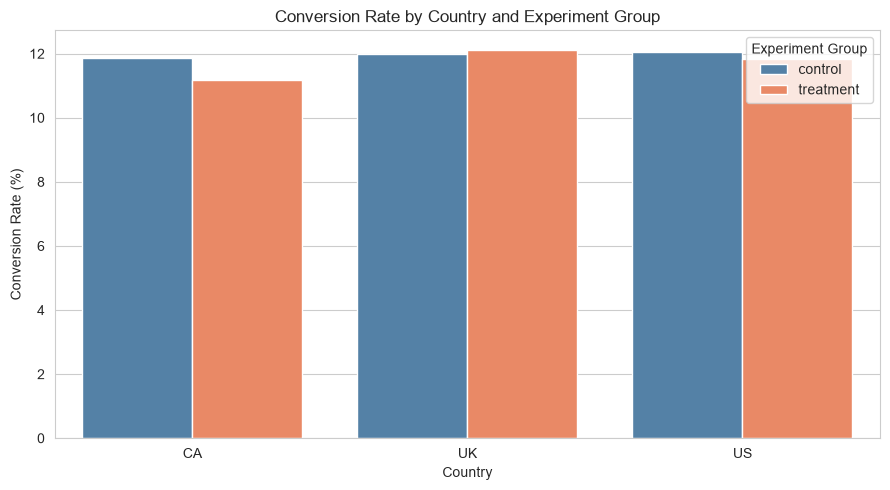

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# conversion rate by country and group
country_data = (
    df.groupby(["country", "group"])["converted"]
    .mean().reset_index()
)

country_data["converted"] *= 100

#grouped bar chart
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=country_data,
    x="country",
    y="converted",
    hue="group",
    hue_order=["control", "treatment"],
    palette=["steelblue", "coral"]
)

plt.title("Conversion Rate by Country and Experiment Group")
plt.xlabel("Country")
plt.ylabel("Conversion Rate (%)")
plt.legend(title="Experiment Group")

plt.tight_layout()
plt.show()

## 5.1 Hypothesis Testing — Test 1: T-Test

In [27]:
from scipy.stats import ttest_ind
control=df[df["group"]=="control"]["converted"]
treatment=df[df["group"]=="treatment"]["converted"]
t_stat, p_value = ttest_ind(
    control,
    treatment,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.310922637465592
P-value: 0.18988493791578315


##### OBSERAVTION
###### p-value = 0.1899
###### α = 0.05
###### Since 0.1899 > 0.05, we fail to reject H₀.
###### Since the p-value (0.1899) is greater than the significance level of 0.05, the null hypothesis is not rejected. Therefore, there is insufficient evidence to conclude that the conversion rates of the control and treatment groups are significantly different.

#### 5.2 Hypothesis Testing — Test 2: Chi-Square Test of Independence

In [29]:
contigency_table=pd.crosstab(
    df["group"],
    df["converted"]
)
display(contigency_table)

converted,0,1
group,,
control,127785,17489
treatment,128046,17264


In [30]:
from scipy.stats import chi2_contingency
chi2_stat, p_value, dof, expected = chi2_contingency(
    contigency_table
)
print("Chi-square statistic:", chi2_stat)
print("P-value:", p_value)

Chi-square statistic: 1.7035660051885058
P-value: 0.19182228096235662


#### Observation
###### The Chi-Square Test of Independence produced a chi-square statistic of 1.7036 and a p-value of 0.1918. Since the p-value is greater than the significance level of 0.05, the null hypothesis is not rejected. Therefore, there is insufficient evidence to conclude that experiment group and conversion outcome are significantly associated.

#### 5.3 Hypothesis Testing — Test 3:One-Way Anova

In [ ]:
country_conversion = (
    df.groupby("country")["converted"].mean() * 100
)
print(country_conversion)

country
CA    11.531830
UK    12.059449
US    11.954680
Name: converted, dtype: float64


In [ ]:
ca=df[df["country"]=="CA"]["converted"]
uk=df[df["country"]=="UK"]["converted"]
us=df[df["country"]=="US"]["converted"]
from scipy.stats import f_oneway
f_stat,p_value=f_oneway(ca,uk,us)
print("F-statistic:",f_stat)
print("P-value:",p_value)

F-statistic: 1.6052863959236454
P-value: 0.2008338102216087


##### Observation
###### The one-way ANOVA produced an F-statistic of 1.6053 and a p-value of 0.2008. Since the p-value is greater than the significance level of 0.05, the null hypothesis is not rejected. Therefore, there is insufficient evidence to conclude that conversion rates differ significantly among CA, UK, and US.